In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 12
colors = sns.color_palette('pastel')[0:6]
df = pd.read_csv("dataset/contribution.csv")

In [2]:
df

,Gender,Class Year,Marital Status,Major,Next Degree,FY04Giving,FY03Giving,FY02Giving,FY01Giving,FY00Giving,AttendenceEvent
0,M,1957,M,History,LLB,2500.0,2500.0,1400.0,12060.0,12000.0,1
1,M,1957,M,Physics,MS,5000.0,5000.0,5000.0,5000.0,10000.0,1
2,F,1957,M,Music,NONE,5000.0,5000.0,5000.0,5000.0,10000.0,1
3,M,1957,M,History,NONE,0.0,5100.0,200.0,200.0,0.0,1
4,M,1957,M,Biology,MD,1000.0,1000.0,1000.0,1005.0,1000.0,1
...,...,...,...,...,...,...,...,...,...,...,...
1225,M,1997,M,Art,NONE,0.0,0.0,0.0,0.0,0.0,0
1226,F,1997,M,Art,NDA,0.0,0.0,0.0,0.0,0.0,0
1227,F,1997,S,Spanish,NDA,10.0,20.0,20.0,20.0,20.0,0
1228,F,1997,S,Spanish,NONE,25.0,0.0,0.0,10.0,0.0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1230 entries, 0 to 1229
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           1230 non-null   object 
 1   Class Year       1230 non-null   int64  
 2   Marital Status   1230 non-null   object 
 3   Major            1230 non-null   object 
 4   Next Degree      1230 non-null   object 
 5   FY04Giving       1230 non-null   float64
 6   FY03Giving       1230 non-null   float64
 7   FY02Giving       1230 non-null   float64
 8   FY01Giving       1230 non-null   float64
 9   FY00Giving       1230 non-null   float64
 10  AttendenceEvent  1230 non-null   int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 105.8+ KB


In [4]:
df.isnull().sum()

Gender             0
Class Year         0
Marital Status     0
Major              0
Next Degree        0
FY04Giving         0
FY03Giving         0
FY02Giving         0
FY01Giving         0
FY00Giving         0
AttendenceEvent    0
dtype: int64

In [14]:
def group_top_n(df, column, n=5):
    top_values = df[column].value_counts().nlargest(n).index
    return df[column].apply(lambda x: x if x in top_values else 'Others')

Task 2: Vẽ biểu đồ pie chart theo Gender

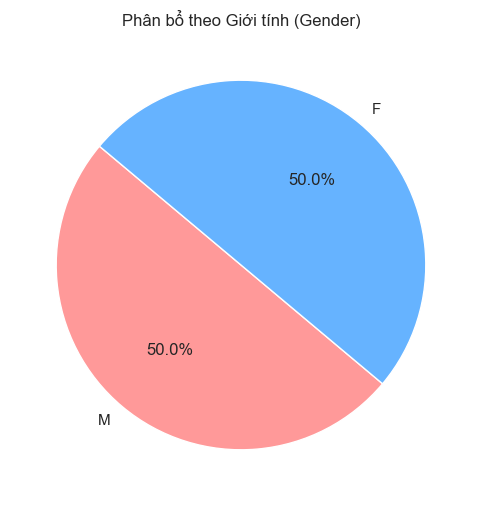

In [18]:
plt.figure(figsize=(6, 6))
gender_counts = df['Gender'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title('Phân bổ theo Giới tính (Gender)')
plt.show()

Task 3: Vẽ biểu đồ pie chart theo Major

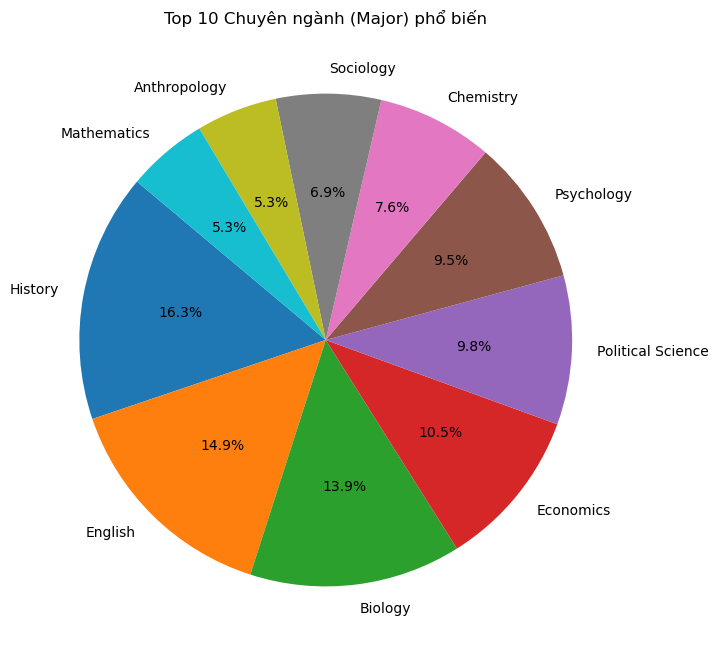

In [6]:
plt.figure(figsize=(8, 8))
major_counts = df['Major'].value_counts().head(10) 
plt.pie(major_counts, labels=major_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Top 10 Chuyên ngành (Major) phổ biến')
plt.show()

Task 4: Vẽ biểu đồ pie chart theo Next Degree

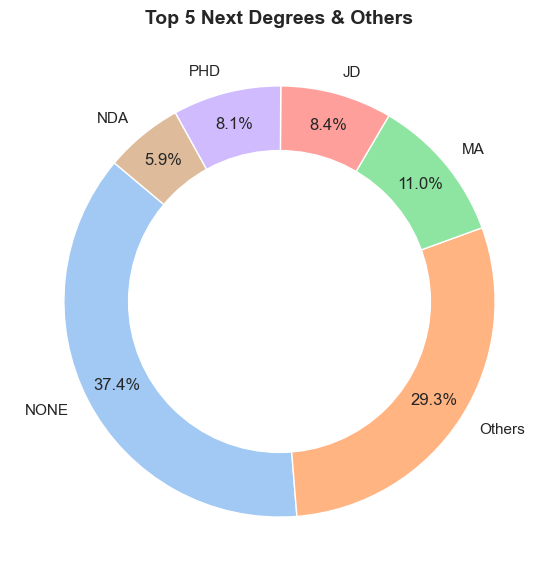

In [15]:
plt.figure(figsize=(7, 7))
degree_data = group_top_n(df, 'Next Degree', 5).value_counts()
plt.pie(degree_data, labels=degree_data.index, autopct='%1.1f%%', startangle=140, colors=colors, pctdistance=0.85)
plt.gca().add_artist(plt.Circle((0,0), 0.70, fc='white'))
plt.title('Top 5 Next Degrees & Others', fontsize=14, fontweight='bold')
plt.show()

Task 5: Vẽ 3 biểu đồ Marital Status theo năm

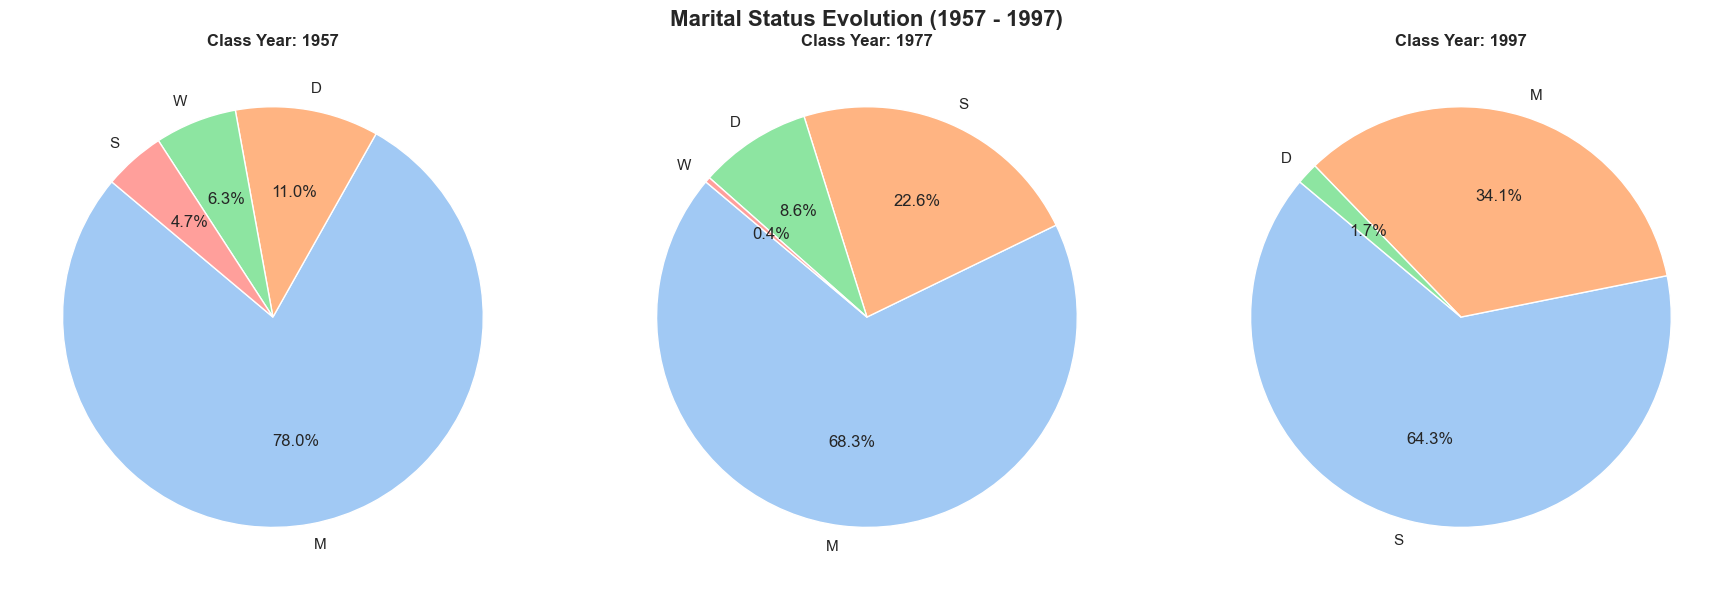

In [20]:
years = [1957, 1977, 1997]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, year in enumerate(years):
    data_year = df[df['Class Year'] == year]
    counts = data_year['Marital Status'].value_counts()
    axes[i].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, colors=colors)
    axes[i].set_title(f'Class Year: {year}', fontweight='bold')

plt.suptitle('Marital Status Evolution (1957 - 1997)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

 Nhận xét: 
- Nhóm 1957: Hầu hết đã kết hôn (M).
- Nhóm 1977: Tỷ lệ độc thân (S) bắt đầu tăng.
- Nhóm 1997: Đa số vẫn đang độc thân (S) do mới tốt nghiệp không lâu.